In [1]:
import numpy as np
from scipy.optimize import minimize
from pyscf import scf, qmmm, gto
import MDAnalysis as mda
# import sys; sys.path.append('../')
import H2O_hydroxide as Hh
from importlib import reload  # Python 3.4+

In [2]:
# ============================================================
# Constants
# ============================================================

HARTREE_TO_KJMOL = 2625.49962

In [3]:
# ============================================================
# TIP4P-D reference geometry
# ============================================================
water_H1_ref, water_H2_ref, water_M_ref = Hh.get_water_ref()

In [4]:
# ============================================================
# OH-
#
# O-H distance = 0.97 Å
#
# Charge = -1
# ============================================================

mol = gto.M(
    atom='''
        O    0.000    0.000    0.000
        H    0.970    0.000    0.000
    ''',
    basis='sto-3g',
    charge=-1,
    spin=0,
    unit='Angstrom',
    verbose=4
)

System: uname_result(system='Linux', node='Cas2', release='6.1.177-1-MANJARO', version='#1 SMP PREEMPT_DYNAMIC Sat Jul  4 22:18:29 UTC 2026', machine='x86_64')  Threads 32
Python 3.14.6 (main, Jun 15 2026, 11:36:54) [GCC 16.1.1 20260430]
numpy 2.5.1  scipy 1.18.0  h5py 3.16.0
Date: Fri Aug 21 13:49:12 2026
PySCF version 2.14.0
PySCF path  /home/chemistry/venvs/jupyter/lib/python3.14/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 10
[INPUT] charge = -1
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 O      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0
[INPUT]  2 H      0.970000000000   0.000000000000   0.000000000000 AA    1.833034340828   0.000000000

In [5]:
# ============================================================
# BARE QM ENERGY
# ============================================================

mf_qm = scf.RHF(mol)

energy_qm_hartree = mf_qm.kernel()

energy_qm_kjmol = (
    energy_qm_hartree * HARTREE_TO_KJMOL
)



******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmpvyf52u_s
max_memory 4000 MB (current use 192 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -73.9765896919984
  HOMO = -0.336126307462798  LUMO = 0.488509951930399  gap/eV = 22.43950
cycle= 1 E= -73.9300784358368  delta_E= 0.0465  |g|= 0.529  |ddm|=  1.5
  HOMO = 0.414541082916799  LUMO = 1.24739187792405  gap/eV = 22.66302
cycle= 2 E= -74.0560473499752  delta_E= -0.126  |g|= 0.0535  |ddm|= 0.869
  HOMO = 0.251789068399815  LUMO = 1.24576848161727  gap/eV = 27.04756
cycle= 3 E= -74.0573907484135  delta_E= -0.00134  |g|= 0.00458  |ddm|= 0.11
  HOMO = 0.251112681742945  LUMO = 1.24325478899864  gap/eV = 2

In [6]:
# ============================================================
# LJ PARAMETERS
# ============================================================

lj_params = {

    "OH_O": {
        "sigma_A": 3.400,
        "epsilon_kJmol": 0.2508914038369354
    },

    "OH_H": {
        "sigma_A": 1.443,
        "epsilon_kJmol": 0.18390926154006562
    },

    # TEST TIP4P-D oxygen parameters
    "TIP4P_O": {
        "sigma_A": 3.15365,
        "epsilon_kJmol": 0.650194
    }
}


qm_coords = mol.atom_coords(unit='Angstrom')
qm_atom_types = [
    "OH_O",
    "OH_H"
]

x0_xyz = np.array([
    3.5,
    0.0,
    0.0,
    0.0,    # rotation x (radians)
    0.0,    # rotation y
    0.0     # rotation z
])
print("Initial variables:")
print(x0_xyz)

print(
    f"Initial energy = "
    f"{Hh.total_qm_water_energy(x0_xyz,water_H1_ref,water_H2_ref,water_M_ref,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params):.6f} kJ/mol"
)


Initial variables:
[3.5 0.  0.  0.  0.  0. ]
Initial energy = -16.769262 kJ/mol


In [7]:
energies = []
actual_distances = []
optimized_molecules = []
mean_field_objects = []
current_mol = mol

In [11]:
# ============================================================
# Optimize water position + orientation
# ============================================================

result = minimize(
    Hh.total_qm_water_energy, x0_xyz, args=(water_H1_ref,water_H2_ref,water_M_ref,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params),
    method="L-BFGS-B",
    # bounds=[
    #     (1.5, 6.0),    # x
    #     (-4.0, 4.0),   # y
    #     (-4.0, 4.0)    # z
    # ],
    options={
        "maxiter": 30,
        "ftol": 1e-6,
        "gtol": 1e-4
    }
)
print()
print("======================================================")
print("             WATER OPTIMIZATION")
print("======================================================")

print()
print("Success:")
print(result.success)

print()
print("Message:")
print(result.message)

print()
print("Number of function evaluations:")
print(result.nfev)

print()
print("Initial energy:")
print(
    f"{Hh.total_qm_water_energy(x0_xyz,water_H1_ref,water_H2_ref,water_M_ref,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params):.6f} kJ/mol"
)

print()
print("Final energy:")
print(
    f"{result.fun:.6f} kJ/mol"
)

print()
print("Optimized variables:")
print(result.x)

print()
print("Optimization gradient:")
print(result.jac)

print()
print("Maximum absolute gradient component:")
print(np.max(np.abs(result.jac)))


             WATER OPTIMIZATION

Success:
True

Message:
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Number of function evaluations:
266

Initial energy:
-16.769262 kJ/mol

Final energy:
-104.199921 kJ/mol

Optimized variables:
[-0.47651083 -2.49511652  0.01223395 -0.00998141  0.01500375 -0.99227077]

Optimization gradient:
[ 0.01080878 -0.01571152  0.01312088  0.01455192  0.01164153 -0.00291038]

Maximum absolute gradient component:
0.01571152106861365


In [13]:
print()
print("======================================================")
print("       FINITE-DIFFERENCE GRADIENT CHECK")
print("======================================================")

x_opt = result.x.copy()

delta = 1.0e-2   # Å for translation, radians for rotation

for i in range(6):

    xp = x_opt.copy()
    xm = x_opt.copy()

    xp[i] += delta
    xm[i] -= delta

    Ep = Hh.total_qm_water_energy(
        xp,
        water_H1_ref,
        water_H2_ref,
        water_M_ref,
        mol,
        energy_qm_kjmol,
        qm_coords,
        qm_atom_types,
        lj_params
    )

    Em = Hh.total_qm_water_energy(
        xm,
        water_H1_ref,
        water_H2_ref,
        water_M_ref,
        mol,
        energy_qm_kjmol,
        qm_coords,
        qm_atom_types,
        lj_params
    )

    numerical_gradient = (Ep - Em) / (2.0 * delta)

    print(
        f"{i}:  "
        f"finite difference = {numerical_gradient: .8f}   "
        f"L-BFGS-B = {result.jac[i]: .8f}"
    )


       FINITE-DIFFERENCE GRADIENT CHECK
0:  finite difference =  0.00491884   L-BFGS-B =  0.01080878
1:  finite difference =  0.04868681   L-BFGS-B = -0.01571152
2:  finite difference =  0.00623990   L-BFGS-B =  0.01312088
3:  finite difference =  0.01282760   L-BFGS-B =  0.01455192
4:  finite difference =  0.00730997   L-BFGS-B =  0.01164153
5:  finite difference = -0.01716262   L-BFGS-B = -0.00291038


In [9]:
# ============================================================
# Energy breakdown at optimized geometry
# ============================================================
O_opt, H1_opt, H2_opt, M_opt = \
    Hh.water_from_6dof(
        result.x,
        water_H1_ref,
        water_H2_ref,
        water_M_ref
    )
print("Optimized water:")
print("O :", O_opt)
print("H1:", H1_opt)
print("H2:", H2_opt)
print("M :", M_opt)

# ------------------------------------------------------------
# Electrostatic interaction
# ------------------------------------------------------------

mm_charge_coords = np.array([
    H1_opt,
    H2_opt,
    M_opt
])

mm_charges = np.array([
    +0.58,
    +0.58,
    -1.16
])

mf_qm = scf.RHF(mol)
mf_qm.verbose = 0

mf_qmmm = qmmm.mm_charge(
    mf_qm,
    mm_charge_coords,
    mm_charges,
    unit='Angstrom'
)

mf_qmmm.verbose = 0

energy_qmmm_hartree = mf_qmmm.kernel()

energy_qmmm_kjmol = (
    energy_qmmm_hartree * HARTREE_TO_KJMOL
)

E_elec = (
    energy_qmmm_kjmol
    - energy_qm_kjmol
)

# ------------------------------------------------------------
# LJ interaction
# ------------------------------------------------------------

E_LJ = Hh.lj_energy(
    qm_coords,
    qm_atom_types,
    np.array([O_opt]),
    ["TIP4P_O"],
    lj_params
)

# ------------------------------------------------------------
# Total
# ------------------------------------------------------------

E_total = E_elec + E_LJ

print()
print("Energy breakdown:")
print(f"Electrostatic = {E_elec:12.6f} kJ/mol")
print(f"LJ            = {E_LJ:12.6f} kJ/mol")
print(f"Total         = {E_total:12.6f} kJ/mol")

Optimized water:
O : [-0.47627893 -2.49507561 -0.02223825]
H1: [ 0.42635126 -2.80738469 -0.08678876]
H2: [-0.39949174 -1.54097163 -0.00693081]
M : [-0.3500912  -2.41238702 -0.0285827 ]

Energy breakdown:
Electrostatic =  -130.792309 kJ/mol
LJ            =    26.592751 kJ/mol
Total         =  -104.199558 kJ/mol


Number of frames: 2


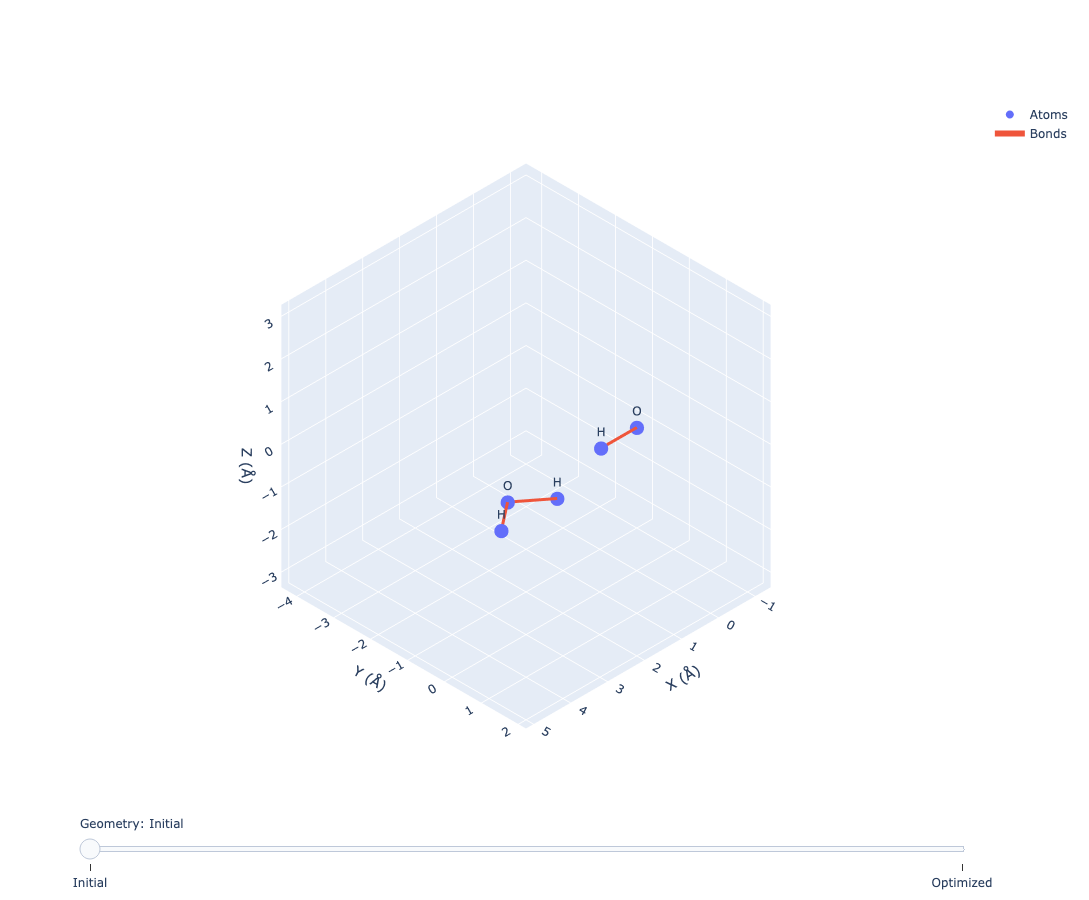

In [10]:
# Save to pick up later by ChimeraX
reload(Hh)
optimization_file = "optimization.xyz"
Hh.savexyz(
    optimization_file,
    x0_xyz,
    mol,
    result,
    water_H1_ref,
    water_H2_ref,
    water_M_ref
)
# Display right now
u = mda.Universe(optimization_file, format="XYZ")
print("Number of frames:", len(u.trajectory))
Hh.visualize_H2O_hydroxide(u)